# Datathon Passos Mágicos - Análise Exploratória e Storytelling

Este notebook responde às 11 perguntas do desafio com base na base consolidada analítica e, quando necessário, na base reduzida para modelagem.

## Objetivos
- Entender a evolução dos indicadores pedagógicos, psicossociais e de engajamento;
- Identificar padrões de risco de defasagem;
- Avaliar a efetividade do programa ao longo dos anos e fases;
- Preparar insumos para o modelo preditivo e para o storytelling da apresentação final.

## Bases utilizadas
- Base analítica consolidada: `base_PEDE_consolidada_analitica.parquet`
- Base reduzida para ML: `base_processada_reduzida_ML.parquet`

In [1]:
# 2) Imports e configuraçãoimport warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [2]:
# 3) Carga das bases
df = pd.read_parquet("../data/processed/base_PEDE_consolidada_analitica.parquet")
df_ml = pd.read_parquet("../data/processed/base_processada_reduzida_ML.parquet")

print("Base analítica:", df.shape)
print("Base ML:", df_ml.shape)

display(df.head())
display(df_ml.head())


Base analítica: (3030, 55)
Base ML: (3030, 16)


,ano_pede,ra,fase,turma,nome,ano_nasc,data_nasc,idade,genero,ano_ingresso,instituicao_ensino,escola,ativo_inativo,pedra_2020,pedra_2021,pedra_2022,pedra_2023,pedra_2024,inde_2022,inde_2023,inde_2024,cg,cf,ct,n_av,avaliador_1,rec_av1,avaliador_2,rec_av2,avaliador_3,rec_av3,avaliador_4,rec_av4,avaliador_5,rec_av5,avaliador_6,rec_av6,iaa,ieg,ips,ipp,rec_psicologia,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,destaque_ieg,destaque_ida,destaque_ipv
0,2022,RA-1,7,A,Aluno-1,2003.0,NaT,19.0,Menina,2016,Escola Pública,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.783,NaN,NaN,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.3,4.1,5.6,NaN,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,2022,RA-2,7,A,Aluno-2,2005.0,NaT,17.0,Menina,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.055,NaN,NaN,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,8.8,5.2,6.3,NaN,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,2022,RA-3,7,A,Aluno-3,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ágata,<NA>,<NA>,6.591,NaN,NaN,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,0.0,7.9,5.6,NaN,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,2022,RA-4,7,A,Aluno-4,2005.0,NaT,17.0,Menino,2017,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Quartzo,<NA>,<NA>,5.951,NaN,NaN,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,None,None,None,None,8.8,4.5,5.6,NaN,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,2022,RA-5,7,A,Aluno-5,2005.0,NaT,17.0,Menina,2016,Rede Decisão,<NA>,<NA>,Ametista,Ametista,Ametista,<NA>,<NA>,7.427,NaN,NaN,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,None,None,None,None,7.9,8.6,5.6,NaN,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


,ano_pede,inde,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,risco_defasagem_atual
0,2022,5.783,4.0,8.3,4.1,5.6,NaN,4.0,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1,0
1,2022,7.055,4.0,8.8,5.2,6.3,NaN,6.8,6.3,4.5,9.7,6.778,10.0,Fase 7 (3º EM),0,0
2,2022,6.591,4.0,0.0,7.9,5.6,NaN,5.6,5.8,4.0,6.9,7.556,10.0,Fase 7 (3º EM),0,0
3,2022,5.951,4.0,8.8,4.5,5.6,NaN,5.0,2.8,3.5,8.7,5.278,10.0,Fase 7 (3º EM),0,0
4,2022,7.427,4.0,7.9,8.6,5.6,NaN,5.2,7.0,2.9,5.7,7.389,10.0,Fase 7 (3º EM),0,0


In [3]:
# 4) Padronizações auxiliares
# cria coluna inde única na base analítica
df["inde"] = np.nan

if "inde_2022" in df.columns:
    df.loc[df["ano_pede"] == 2022, "inde"] = df["inde_2022"]
if "inde_2023" in df.columns:
    df.loc[df["ano_pede"] == 2023, "inde"] = df["inde_2023"]
if "inde_2024" in df.columns:
    df.loc[df["ano_pede"] == 2024, "inde"] = df["inde_2024"]

# garantir numéricos
cols_numericas = [
    "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
    "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
]

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# categorias úteis
for col in ["fase", "turma", "genero", "instituicao_ensino", "pedra_2022", "pedra_2023", "pedra_2024"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ano_pede            3030 non-null   int64         
 1   ra                  3030 non-null   string        
 2   fase                3030 non-null   string        
 3   turma               3030 non-null   string        
 4   nome                3030 non-null   string        
 5   ano_nasc            860 non-null    float64       
 6   data_nasc           2170 non-null   datetime64[ns]
 7   idade               2631 non-null   float64       
 8   genero              3030 non-null   string        
 9   ano_ingresso        3030 non-null   int64         
 10  instituicao_ensino  3029 non-null   string        
 11  escola              1155 non-null   string        
 12  ativo_inativo       0 non-null      string        
 13  pedra_2020          754 non-null    string      

In [4]:
# 5) Funções auxiliares
def plot_bar(data, x, y, title, figsize=(10,5), rotation=0):
    plt.figure(figsize=figsize)
    sns.barplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_line(data, x, y, hue=None, title="", figsize=(10,5), rotation=0, marker="o"):
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_heatmap_corr(df_corr, title="Mapa de Correlação"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def categorizar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    if valor <= 0:
        return "Sem defasagem"
    elif valor == 1:
        return "Defasagem leve"
    elif valor == 2:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"

df["categoria_defasagem"] = df["defasagem"].apply(categorizar_defasagem)

### 8. Multidimensionalidade dos indicadores

,inde
inde,1.000000
ida,0.785311
ieg,0.745330
ipv,0.720896
ipp,0.540295
iaa,0.397226
ips,0.199618


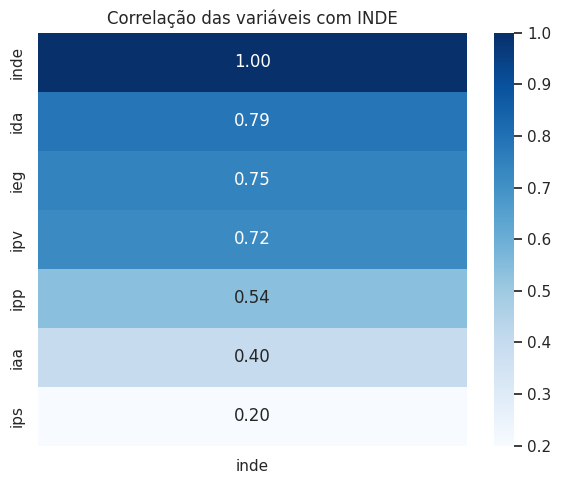

In [5]:
# 33) Correlação com INDE
cols_inde = [c for c in ["inde", "ida", "ieg", "ips", "ipp", "iaa", "ipv"] if c in df.columns]
corr_inde = df[cols_inde].corr()[["inde"]].sort_values("inde", ascending=False)

display(corr_inde)

plt.figure(figsize=(6,5))
sns.heatmap(corr_inde, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlação das variáveis com INDE")
plt.tight_layout()
plt.show()

### Interpretação dos resultados - 33) Correlação com INDE



,faixa_ida,faixa_ieg2,inde
0,IDA baixo,IEG baixo,5.953958
1,IDA baixo,IEG médio,6.793149
2,IDA baixo,IEG alto,7.214395
3,IDA médio,IEG baixo,6.863838
4,IDA médio,IEG médio,7.322612
5,IDA médio,IEG alto,7.752456
6,IDA alto,IEG baixo,7.427894
7,IDA alto,IEG médio,7.899868
8,IDA alto,IEG alto,8.333675


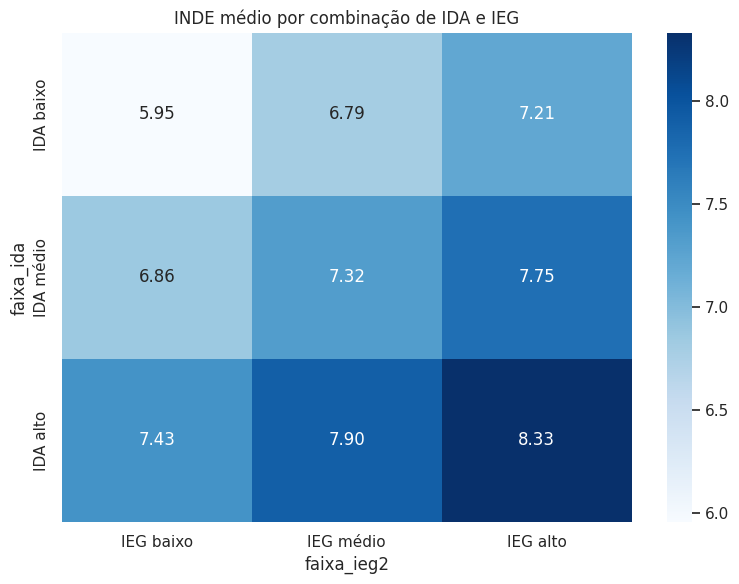

In [6]:
# 34) Faixas combinadas de desempenho e engajamento
df["faixa_ida"] = pd.qcut(df["ida"], q=3, labels=["IDA baixo", "IDA médio", "IDA alto"])
df["faixa_ieg2"] = pd.qcut(df["ieg"], q=3, labels=["IEG baixo", "IEG médio", "IEG alto"])

combo = (
    df.groupby(["faixa_ida", "faixa_ieg2"], observed=False)["inde"]
      .mean()
      .reset_index()
)

display(combo)

pivot_combo = combo.pivot(index="faixa_ida", columns="faixa_ieg2", values="inde")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_combo, annot=True, cmap="Blues", fmt=".2f")
plt.title("INDE médio por combinação de IDA e IEG")
plt.tight_layout()
plt.show()

### Interpretação dos resultados - 34) Correlação com INDE


In [7]:
# 35) Combinação ampliada
for col in ["ips", "ipp"]:
    df[f"faixa_{col}"] = pd.qcut(df[col], q=2, labels=[f"{col.upper()} baixo", f"{col.upper()} alto"])

combo_ampla = (
    df.groupby(["faixa_ida", "faixa_ieg2", "faixa_ips", "faixa_ipp"], observed=False)["inde"]
      .mean()
      .reset_index()
      .sort_values("inde", ascending=False)
)

display(combo_ampla.head(10))

,faixa_ida,faixa_ieg2,faixa_ips,faixa_ipp,inde
35,IDA alto,IEG alto,IPS alto,IPP alto,8.598127
34,IDA alto,IEG alto,IPS alto,IPP baixo,8.376228
31,IDA alto,IEG médio,IPS alto,IPP alto,8.254413
33,IDA alto,IEG alto,IPS baixo,IPP alto,8.234747
32,IDA alto,IEG alto,IPS baixo,IPP baixo,8.132583
23,IDA médio,IEG alto,IPS alto,IPP alto,8.091139
30,IDA alto,IEG médio,IPS alto,IPP baixo,7.991793
27,IDA alto,IEG baixo,IPS alto,IPP alto,7.869882
29,IDA alto,IEG médio,IPS baixo,IPP alto,7.838672
22,IDA médio,IEG alto,IPS alto,IPP baixo,7.795749


### # 35) Combinação ampliada Análise a ser gerada 

### Leitura analítica
- O INDE tende a ser mais alto quando múltiplos indicadores caminham juntos.
- A análise combinada ajuda a mostrar que o sucesso do aluno é multidimensional e não depende apenas da nota acadêmica.